# Preliminaries

## Dataset

In this set of exercises we will use the same dataset as from [week 3](week_3.ipynb). 


As before, we provide the data already curated in the following two files:

`RNA_expression_curated.csv`: [148 cell lines , 238 genes]

`drug_response_curated.csv`: [148 cell lines , YM155 drug]

The curated data can be read as `pandas` `DataFrame` in the following way:

In [ ]:
import pandas as pd

gene_expression = pd.read_csv("./data/RNA_expression_curated.csv", sep=',', header=0, index_col=0)
drug_response = pd.read_csv("./data/drug_response_curated.csv", sep=',', header=0, index_col=0)

The goal of the exercises is to train support vector machine (SVM) and random forests classifiers on this dataset and explore and learn about their hyperparameters. 

## Tools

The `scikit-learn` library provides the required tools for support vector machines, as well as for random forest algorithms.

In [ ]:
from sklearn import svm 
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_blobs, make_circles
from sklearn.metrics import classification_report

Before proceeding, look up the documentation of the imported functions and read about their basic functionality. Below, we list some important parameters of SVMs and random forests that can be tuned during training.

#### Support Vector Machines (SVM)

`C`: error term.

`kernel`: similarity function ('linear', 'poly', 'sigmoid' or 'rbf')

`gamma`: kernel coef. for 'rbf', 'poly' and 'sigmoid' kernels. It can be thought of as the ‘spread’ of the kernel and therefore the decision region.

`degree`: degree for the 'poly' kernel.

`coef0`: independt term in the 'poly' and 'sigmoid' kernels


#### Random Forests

`n_estimators`: number of trees in our random forest.

`max_depth`: maximum number of levels in each decision tree

`max_features`: maximum number of features to consider per split in an individual tree.

`min_sample_leaf`: minimum number of data points per leaf node

`min_samples_split`: minimum number of data points placed in a node before the node is split

`oob_score`: the out-of-bag (OOB) error is the average error for each observation calculated using predictions from the trees that do not contain that observation in their respective bootstrap sample. Set this parameter to true.

`bootstrap`: method for sampling data points (with or without replacement). Set this parameter to true.

`criterion`: function used to measure the quality of the split (e.g. 'entropy' or 'gini')

# Exercises

## Support vector machines

The  `make_blobs` and `make_circles` functions can be used to generate linearly and not linearly separable toy datasets. 

In [ ]:
# data generation: linearly separable
X, Y = make_blobs(n_samples=200, centers=2, n_features=2, random_state=1234)
X = pd.DataFrame(X, columns=['x1', 'x2'])

# splitting data into training and test set
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.33, random_state=333)

The following code illustrates how to train a linear SVM classifier and plot the data points, the separating hyperplane, the support vectors and the margins that pass through them (considering the training data)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# build the model
model = svm.SVC(kernel='linear', random_state=33)
model.fit(X_train, Y_train)

# create plot
fig, ax = plt.subplots()

# get colors from qualitative colormap 'Paired'
cmap = plt.cm.get_cmap('Paired')

# plot data points
ax.scatter(X_train.iloc[Y_train == 1, 0], X_train.iloc[Y_train == 1, 1],
           c=[cmap(11)], label='1')
ax.scatter(X_train.iloc[Y_train == 0, 0], X_train.iloc[Y_train == 0, 1],
           c=[cmap(0)], label='0')
ax.legend(loc='best')

# plot the decision function
# create grid to evaluate model
x1_min, x1_max = X_train.iloc[:, 0].min() - 1, X_train.iloc[:, 0].max() + 1
x2_min, x2_max = X_train.iloc[:, 1].min() - 1, X_train.iloc[:, 1].max() + 1

XX, YY = np.meshgrid(np.arange(x1_min, x1_max, .2),
                     np.arange(x2_min, x2_max, .2))

xy = np.vstack([XX.ravel(), YY.ravel()]).T
Z = model.decision_function(xy).reshape(XX.shape)

# plot decision boundary and margins
ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5,
           linestyles=['--', '-', '--'])

# Establish the class for each point in the contour
Z = model.predict(xy).reshape(XX.shape)

# Visualization of the contour
ax.contourf(XX, YY, Z, cmap='bwr', alpha=0.3)

# plot support vectors, whose are responsible for building the margins
ax.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1], s=100,
           linewidth=1, facecolors='none', edgecolors='k', marker='s')

ax.axis([x1_min, x1_max, x2_min, x2_max])
plt.axis('tight')
plt.title('Linear kernel SVM')
plt.show()

Train a radial basis function (RBF) SVM classifier with `gamma=0.5` and plot the results in the same way.

In [ ]:
# data generation: not linearly separable
X, Y = make_circles(n_samples=200, noise=0.05, random_state=1234)
X = pd.DataFrame(X, columns=['x1', 'x2'])

# splitting data into training and test set
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.33, random_state=333)

<p><font color='#770a0a'>When should a RBF kernel be used over a linear kernel? Motivate your answer.</font></p>

<p><font color='#770a0a'>Do we need to normalize the data before using a kernel function? Motivate your answer.
</font></p>

## Predicting drug response on cell lines from gene expression data with SVMs

Explore the hyper-parameter space of an SVM classifier with cross-validation for the Genomics of Drug Sensitivity in Cancer (GDSC) dataset. The`GridSearchCV` function can be used to specify a grid of parameter values with the `param_grid` parameter.

Calculate the precision of your predictions, and compare your calculations with the results of `classification_report`, which displays many classification metrics.


## Random forests

Follow the same steps as for SVM. Compare the two algorithms and report which one has better performance.

The random forests classifiers allows to perform feature selection. Evaluate the importance of features extracting the top 50 informative features. A bar plot (`plt.bar()`) can be a useful tool to visualize this. 

## Function repo RF vs SVM

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, precision_score, balanced_accuracy_score, f1_score,
    roc_curve, roc_auc_score
)
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression

# Configuration
RNG = 42
TEST_SIZE = 0.25
N_SPLITS = 5
SCORING = "f1"
TOP_N = 50
DATA_EXPR = "./data/RNA_expression_curated.csv"
DATA_RESP = "./data/drug_response_curated.csv"
DRUG_COL_FALLBACK = "YM155"  # fallback if not found in drug_response.columns

# utils
def print_header(title: str):
    '''Print header for sections.'''
    print("\n" + "=" * 8, title, "=" * 8)

def print_metrics(y_true, y_pred, prefix=""):
    '''Print classification metrics.'''
    print(f"{prefix}Balanced accuracy: {balanced_accuracy_score(y_true, y_pred):.3f}") 
    print(f"{prefix}Precision:        {precision_score(y_true, y_pred, zero_division=0):.3f}")
    print(classification_report(y_true, y_pred, digits=3))

# Data loading and splitting
def load_data(expr_path: str, resp_path: str):
    '''Load gene expression and drug response data, create binary target by median split.'''
    gene_expression = pd.read_csv(expr_path, sep=",", header=0, index_col=0)
    drug_response   = pd.read_csv(resp_path, sep=",", header=0, index_col=0)

    drug_col = drug_response.columns[0] if len(drug_response.columns) else DRUG_COL_FALLBACK # fallback
    df = gene_expression.join(drug_response, how="inner") # inner join on index
    X = df[gene_expression.columns].copy() # features 
    y_cont = df[drug_col].astype(float).values # continuous response
    thr = np.median(y_cont) # median split threshold
    y = (y_cont <= thr).astype(int)  # 1 = sensitive, 0 = resistant

    print(f"Classes -> sensitive(1)={y.sum()}, resistant(0)={(y==0).sum()}, threshold={thr:.3f}")
    return X, y, thr

def split_data(X, y, test_size=TEST_SIZE, rng=RNG):
    '''Split data into training and test sets.'''
    return train_test_split(X, y, test_size=test_size, stratify=y, random_state=rng)

def cv_builder(n_splits=N_SPLITS, rng=RNG):
    '''Build cross-validation strategy.'''
    return StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=rng)

# model training
def train_rf(X_train, y_train, cv, scoring=SCORING, rng=RNG):
    '''Train Random Forest model with hyperparameter tuning.'''
    rf_base = RandomForestClassifier(
        n_estimators=400, bootstrap=True, oob_score=True,
        class_weight="balanced", random_state=rng, n_jobs=-1
    ) # base model random forest classifier
    rf_grid = {
        "max_depth": [None, 10, 20],
        "max_features": ["sqrt", 0.3, 0.5],
        "min_samples_split": [2, 5],
        "min_samples_leaf": [1, 2],
        "criterion": ["gini", "entropy"],
    } # hyperparameter grid
    rf_gs = GridSearchCV(rf_base, rf_grid, cv=cv, scoring=scoring, n_jobs=-1, refit=True)
    rf_gs.fit(X_train, y_train)
    return rf_gs.best_estimator_, rf_gs.best_params_

def train_svm(X_train, y_train, cv, scoring=SCORING, rng=RNG):
    '''Train SVM (RBF) model with hyperparameter tuning.'''
    svm_pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("svc", SVC(kernel="rbf", class_weight="balanced", probability=False, random_state=rng))
    ]) # pipeline svm
    svm_grid = {"svc__C": [0.1, 1, 10, 100], "svc__gamma": ["scale", 0.01, 0.1, 1.0]} # hyperparameter grid
    svm_gs = GridSearchCV(svm_pipe, svm_grid, cv=cv, scoring=scoring, n_jobs=-1, refit=True) 
    svm_gs.fit(X_train, y_train)
    return svm_gs.best_estimator_, svm_gs.best_params_

# Feature importance analysis
def plot_and_save_top_rf_features(rf_estimator, X, top_n=TOP_N,
                                  csv_path="top50_rf_importances.csv",
                                  fig_path="top50_rf_importances.png"):
    '''Plot and save top-N RF feature importances.'''
    imp = rf_estimator.feature_importances_
    feat_names = X.columns.to_numpy()
    order = np.argsort(imp)[::-1]
    top_n = min(top_n, len(order))
    idx = order[:top_n]

    top_df = pd.DataFrame({"gene": feat_names[idx], "rf_importance": imp[idx]})
    print("\nTop-10 RF features:")
    print(top_df.head(10))
    top_df.to_csv(csv_path, index=False)

    plt.figure(figsize=(9, max(8, top_n * 0.28)))
    plt.barh(range(top_n), top_df["rf_importance"][::-1])
    plt.yticks(range(top_n), top_df["gene"][::-1], fontsize=8)
    plt.xlabel("Random Forest feature importance")
    plt.title("YM155: top-50 genes")
    plt.gca().invert_yaxis()
    plt.subplots_adjust(left=0.42, right=0.98, top=0.92, bottom=0.06)
    plt.tight_layout()
    plt.savefig(fig_path, dpi=200)
    plt.show()

def permutation_importance_test(rf_estimator, X_test, y_test, top_n=TOP_N,
                                csv_path="top50_permutation_importance_test.csv"):
    '''Compute permutation importance on TEST set and save top-N to CSV.'''
    feat_names = X_test.columns.to_numpy()
    perm = permutation_importance(rf_estimator, X_test, y_test, n_repeats=50,
                                  random_state=RNG, n_jobs=-1)
    perm_df = pd.DataFrame({"gene": feat_names, "perm_importance": perm.importances_mean})
    perm_df = perm_df.sort_values("perm_importance", ascending=False)
    print("\nPermutation importance (test) top-10:")
    print(perm_df.head(10))
    perm_df.head(min(top_n, len(perm_df))).to_csv(csv_path, index=False)

# One-gene baselines with ABCB1
def abcb1_baselines(X_train, X_test, y_train, y_test):
    '''Train one-gene baselines using ABCB1.'''
    if "ABCB1" not in X_train.columns:
        print("\nABCB1 not found in columns; skip one-gene baselines.")
        return

    Xi_tr, Xi_te = X_train[["ABCB1"]], X_test[["ABCB1"]]

    # 1) RF op ABCB1
    rf1 = RandomForestClassifier(n_estimators=400, class_weight="balanced", random_state=RNG)
    rf1.fit(Xi_tr, y_train)
    p_rf_te = rf1.predict_proba(Xi_te)[:, 1]
    y_rf1 = (p_rf_te >= 0.5).astype(int)
    print("\nABCB1-only RF:")
    print("  AUROC (test):", f"{roc_auc_score(y_test, p_rf_te):.3f}")
    print("  Balanced acc @0.5:", f"{balanced_accuracy_score(y_test, y_rf1):.3f}")

    # 2) Train-median drempel op ruwe ABCB1
    med_thr = np.median(Xi_tr.values)
    y_med = (Xi_te.values.ravel() <= med_thr).astype(int)
    print("  Balanced acc @train-median:", f"{balanced_accuracy_score(y_test, y_med):.3f}")

    # 3) Logistiek(ABCB1) met Youden-threshold op TRAIN
    logit = Pipeline([
        ("scaler", StandardScaler()),
        ("lr", LogisticRegression(class_weight="balanced", max_iter=5000, random_state=RNG))
    ])
    logit.fit(Xi_tr, y_train)
    p_tr = logit.predict_proba(Xi_tr)[:, 1]
    fpr, tpr, thr = roc_curve(y_train, p_tr)
    t_opt = thr[(tpr - fpr).argmax()]

    p_te = logit.predict_proba(Xi_te)[:, 1]
    y_opt = (p_te >= t_opt).astype(int)
    print("ABCB1 Logistic:")
    print("  AUROC (test):", f"{roc_auc_score(y_test, p_te):.3f}")
    print("  Balanced acc @opt-thr:", f"{balanced_accuracy_score(y_test, y_opt):.3f}")


## Main calling code

Classes -> sensitive(1)=74, resistant(0)=74, threshold=-3.195

======== Random Forests ========
Best params: {'criterion': 'entropy', 'max_depth': None, 'max_features': 0.5, 'min_samples_leaf': 2, 'min_samples_split': 5}
OOB score (train): 0.658
Balanced accuracy: 0.629
Precision:        0.571
              precision    recall  f1-score   support

           0      0.778     0.368     0.500        19
           1      0.571     0.889     0.696        18

    accuracy                          0.622        37
   macro avg      0.675     0.629     0.598        37
weighted avg      0.677     0.622     0.595        37


======== SVM (RBF) ========
Best params: {'svc__C': 1, 'svc__gamma': 0.01}
Balanced accuracy: 0.601
Precision:        0.556
              precision    recall  f1-score   support

           0      0.700     0.368     0.483        19
           1      0.556     0.833     0.667        18

    accuracy                          0.595        37
   macro avg      0.628     0.601  

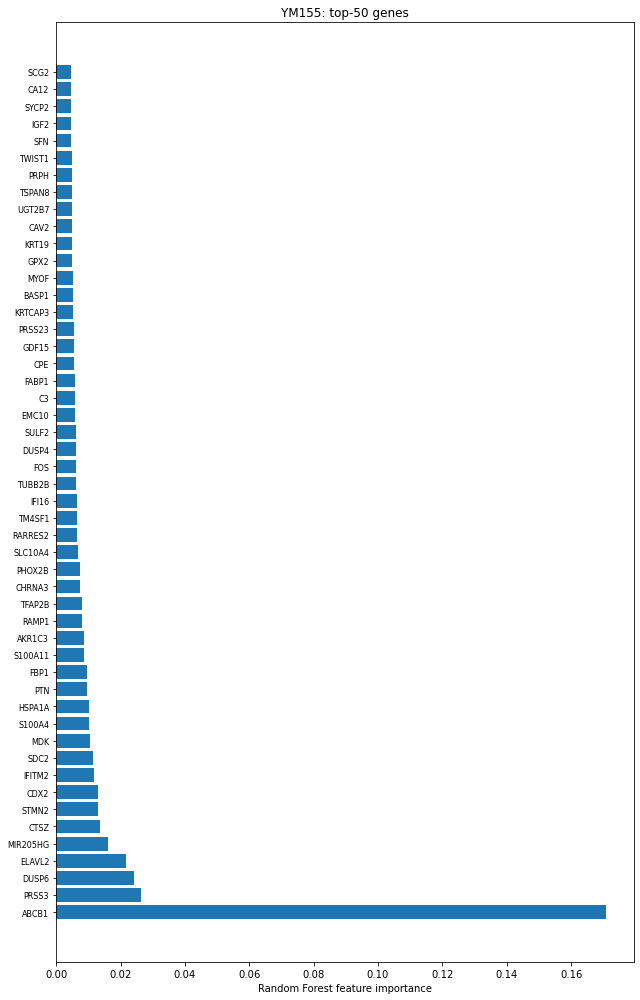


Permutation importance (test) top-10:
         gene  perm_importance
24      ABCB1         0.076216
121     DUSP6         0.001622
119     ANXA3         0.000000
73      VAMP8         0.000000
89       IFI6         0.000000
176  C19orf33         0.000000
87       BMP4         0.000000
177    IGFBP6         0.000000
85      RAB17         0.000000
179    TM4SF4         0.000000

ABCB1-only RF:
  AUROC (test): 0.614
  Balanced acc @0.5: 0.515
  Balanced acc @train-median: 0.683
ABCB1 Logistic:
  AUROC (test): 0.813
  Balanced acc @opt-thr: 0.656


In [2]:
# Data
X, y, thr = load_data(DATA_EXPR, DATA_RESP)
X_train, X_test, y_train, y_test = split_data(X, y)
cv = cv_builder()

# Random Forest
rf_best, rf_params = train_rf(X_train, y_train, cv)
y_rf = rf_best.predict(X_test)
print_header("Random Forests")
print("Best params:", rf_params)
print(f"OOB score (train): {getattr(rf_best, 'oob_score_', np.nan):.3f}")
print_metrics(y_test, y_rf, prefix="")

# SVM (RBF)
svm_best, svm_params = train_svm(X_train, y_train, cv)
y_svm = svm_best.predict(X_test)
print_header("SVM (RBF)")
print("Best params:", svm_params)
print_metrics(y_test, y_svm, prefix="")

# Winner by F1
f1_rf  = f1_score(y_test, y_rf,  zero_division=0)
f1_svm = f1_score(y_test, y_svm, zero_division=0)
print(f"\nWinner by F1: {'RF' if f1_rf >= f1_svm else 'SVM'}  (RF={f1_rf:.3f}, SVM={f1_svm:.3f})")

# Importances
plot_and_save_top_rf_features(rf_best, X, top_n=TOP_N)
permutation_importance_test(rf_best, X_test, y_test, top_n=TOP_N)

# ABCB1 baselines
abcb1_baselines(X_train, X_test, y_train, y_test)

# Random Forests vs SVM on YM155

### Summary

Random Forest performs better than SVM on this YM155 task. The experiment used 148 cell lines and 238 genes. Sensitivity was defined by a median split at −3.195, producing a balanced dataset. A single stratified 75/25 train–test split was used and both models were tuned with 5-fold cross-validation. All reported test metrics come from that fixed split.

---

### Random Forest

- Model: RandomForestClassifier with 400 trees, `class_weight='balanced'`, `bootstrap=True` and OOB enabled.
- Grid-search selections: `criterion=entropy`, `max_depth=None`, `max_faetures=0.5`, `min_samples_leaf=2`, `min_samples_split=5`.

**Test performance (RF):** `balanced accuracy = 0.629`. `precision = 0.571`. `F1 (sensitive) = 0.696`.
**OOB (train):** 0.658

Confusion profile: high recall for sensitive (0.889) vs low recall for resistant (0.368). This is consistent with optimizing F1 on the positive label.

### SVM

- Model: SVM with RBF kernel (after scaling). Best grid point: `C=1`, `gamma=0.01`.

**Test performance (SVM):** `balanced accuracy = 0.601`. `precision = 0.556`. `F1 (sensitive) = 0.667`.

---

### Feature attribution and ABCB1

- The RF impurity importance highlights ABCB1 (importance $\approx$ 0.171).
- Permutation importance on the test set gives ABCB1 $\approx$ 0.076, while most other genes have near-zero permutation effects.

This pattern suggests that most multigene predictive signal is captured by ABCB1. Other genes contribute little marginal information (possible redundancy). The long-tail bar plot of importances matches this observation.

### Single-gene baselines (ABCB1)

- Median-rule on ABCB1 (train median applied to test)  balanced accuracy $\rightarrow$ 0.683.
- Logistic regression on ABCB1 with Youden's J threshold (chosen on train) $\rightarrow$ AUROC $\approx$ 0.813 and balanced accuracy $\approx$ 0.656.

Threshold selection strongly affects one-gene performance. ABCB1 alone provides a strong, easily interpretable baseline.

---

### Discussion and recommendations

- Under the chosen split and metric (F1 for the sensitive class) Random Forest wins.
- SVM's gridpoints `svc_C` & `svc_gamma` are not optimized to the best of the model due to computation time, but with proper tuning SVM could be more accurate!
- Most predictive signal appears concentrated in ABCB1. Should verify with additional splits or nested CV to avoid over-interpreting a single train/test split.
- The ABCB1 median rule or a simple logistic model may be preferable due to interpretability. Random Forests gives a slightly better multivariate model without the need for manual thresholding.


## Biomedical applications

Driven by technological advances, there has recently been a dramatic increase in availability of biomedical data. Machine learning approaches are well suited to take advantage of this data and have been widely applied to many areas of biology. 

Example of these applications are genome annotation, biomarker identification, systems biology, genome data analysis, protein  function  prediction, protein  structure prediction, protein localization prediction, identification of protein interactions and drug discovery.

SVM and RF methods are among the most popular machine learning methods applied in bioinformatics or computational biology.

Perform a literature search and find a biomedical study in which SVM or RF is applied to obtain certain insights. <p><font color='#770a0a'>Explain the motivation behind using that specific algorithm in the study.
</font></p>